In [35]:
import uproot
import pandas as pd
import numpy as np
import glob


In [36]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [37]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [38]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [39]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,415721.000000,415721.000000,415721.000000,415721.000000,415721.000000
mean,1.783456,0.210542,0.456602,1.534714,-0.005819
std,0.152908,0.465937,0.464707,0.864176,0.999984
min,1.500001,-0.999633,-0.892108,0.400001,-1.000000
25%,1.658175,-0.154110,0.155199,0.792370,-1.000000
50%,1.770605,0.265094,0.613898,1.383105,-1.000000
75%,1.927594,0.603785,0.846571,2.121160,1.000000
max,2.099992,0.999976,0.976842,5.339994,1.000000


In [40]:
df_proc13 = df_proc13.query('Dp_M> 1.7 & Dp_M<2.1')


In [41]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,272657.000000,272657.000000,272657.000000,272657.000000,272657.000000
mean,1.872764,0.194131,0.448892,1.565068,-0.005351
std,0.103745,0.471034,0.470075,0.888087,0.999988
min,1.700003,-0.999633,-0.886036,0.400008,-1.000000
25%,1.774961,-0.178709,0.136958,0.801645,-1.000000
50%,1.871838,0.241515,0.608661,1.415409,-1.000000
75%,1.963613,0.592925,0.846090,2.161951,1.000000
max,2.099992,0.999976,0.974742,5.339994,1.000000


In [42]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [43]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_241213_temp"
cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [44]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [45]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,1.576275e+06,1.576275e+06,1.576275e+06,1.576275e+06,1.576275e+06
mean,1.779857e+00,1.950055e-01,4.207933e-01,1.620602e+00,-3.549508e-03
std,1.520445e-01,4.739301e-01,4.623931e-01,8.538606e-01,9.999940e-01
min,1.500000e+00,-9.999192e-01,-8.974629e-01,4.000002e-01,-1.000000e+00
25%,1.655171e+00,-1.765709e-01,1.024990e-01,9.059166e-01,-1.000000e+00
50%,1.763141e+00,2.510684e-01,5.573519e-01,1.502986e+00,-1.000000e+00
75%,1.933878e+00,5.955727e-01,8.142281e-01,2.189087e+00,1.000000e+00
max,2.099998e+00,9.999999e-01,9.734931e-01,5.606323e+00,1.000000e+00


In [46]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.7 & Dp_M<2.1')


In [47]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,1.015029e+06,1.015029e+06,1.015029e+06,1.015029e+06,1.015029e+06
mean,1.871337e+00,1.804198e-01,4.114883e-01,1.651376e+00,-2.684652e-03
std,1.030889e-01,4.802868e-01,4.679745e-01,8.739449e-01,9.999969e-01
min,1.700000e+00,-9.999192e-01,-8.974629e-01,4.000002e-01,-1.000000e+00
25%,1.772138e+00,-2.002029e-01,8.151164e-02,9.228497e-01,-1.000000e+00
50%,1.872339e+00,2.303226e-01,5.484763e-01,1.534547e+00,-1.000000e+00
75%,1.964180e+00,5.871650e-01,8.122049e-01,2.226881e+00,1.000000e+00
max,2.099998e+00,9.999992e-01,9.734931e-01,5.606323e+00,1.000000e+00


In [48]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [49]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity


In [50]:
tree_to_compare = "etapip_gg"
plt.rcParams['font.family'] = 'DejaVu Sans'


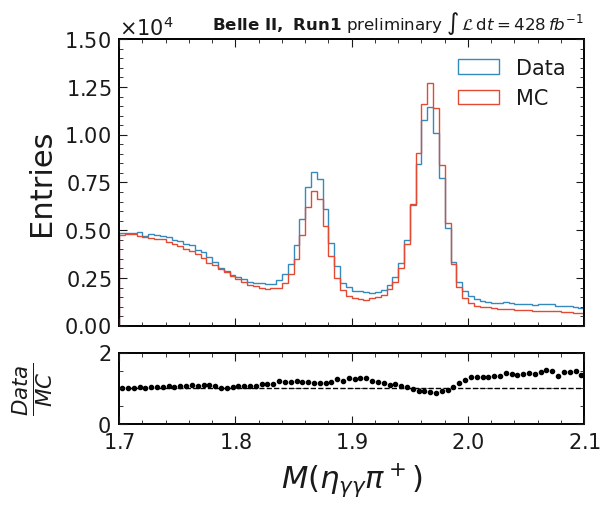

In [52]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{\gamma\gamma} \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.7,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}.png", bbox_inches="tight")